<a href="https://colab.research.google.com/github/apple-pie-h/FDS-LAB-Works/blob/main/LAB_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 7: Develop a simple linear regression model, extend it to multiple linear regression with several variables, and visualize both the regression line and residual plots

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Generate synthetic data for simple linear regression
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10 # Feature
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2 # Target with noise
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2)
# Build and train the simple linear regression model
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)
# Predict on test data
y_pred_simple = simple_lr.predict(X_test)

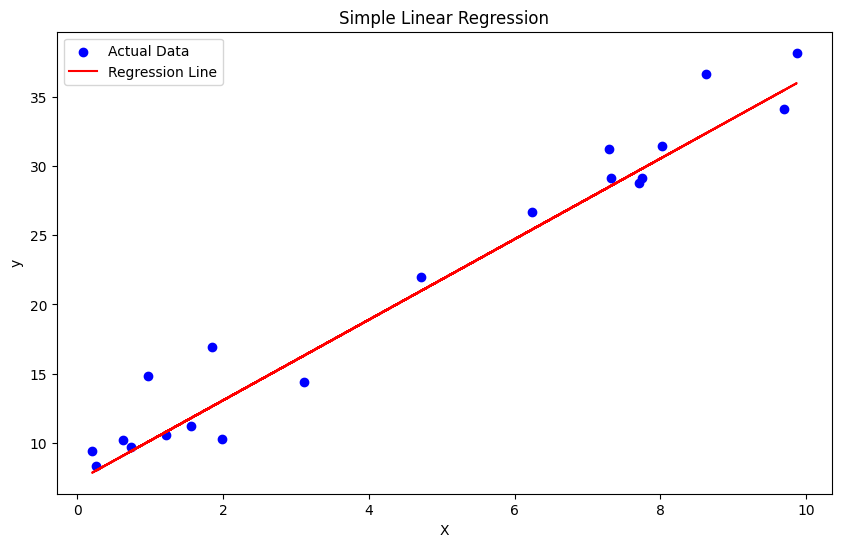

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

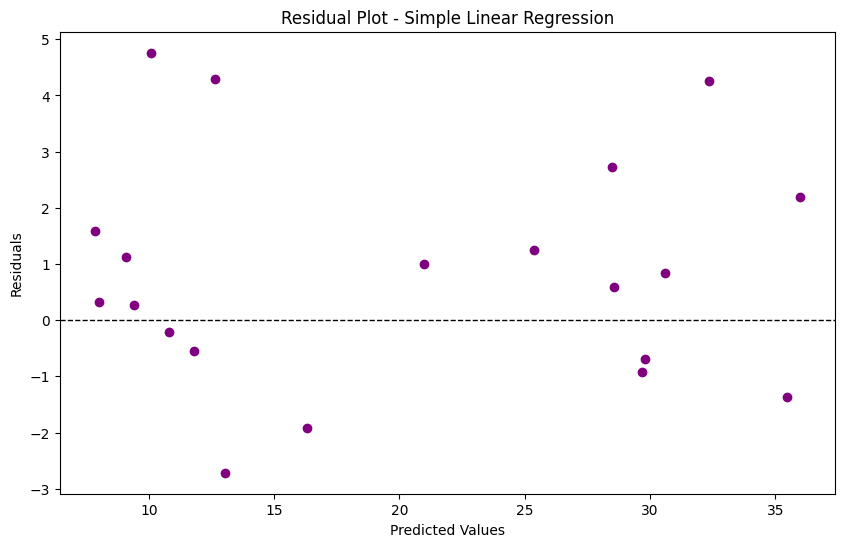

In [4]:
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [6]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10 # 3 features
y_multi = 4 * X_multi[:, 0] + 3 * X_multi[:, 1] - 2 * X_multi[:, 2] + 5 + np.random.randn(100)
# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi)
# Build and train the multiple linear regression model
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)
# Predict on test data
y_pred_multi = multi_lr.predict(X_test_multi)

In [8]:
# Choose one feature to plot (e.g., Feature 0)
feature_index = 0 # Index of the feature to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values
# Generate values for the selected feature
x_values = np.linspace(X_test_multi[:, feature_index].min(), X_test_multi[:, feature_index].max(), num=100)

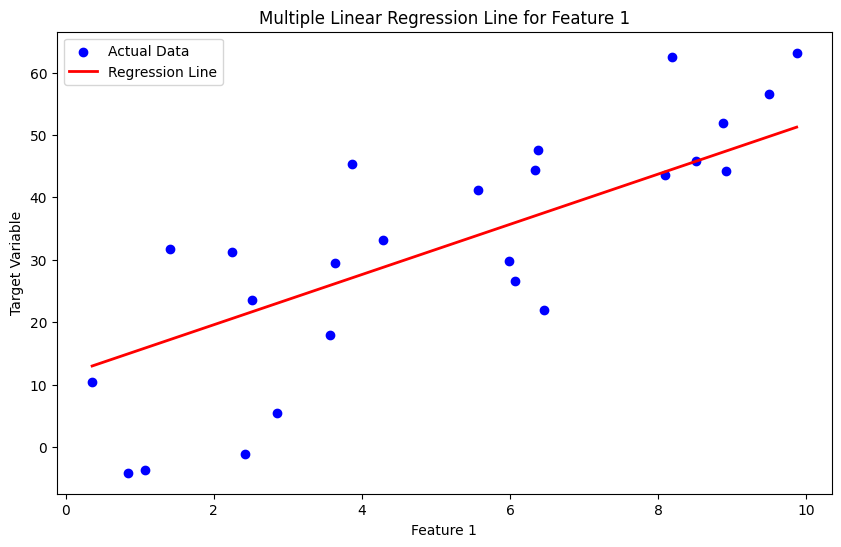

In [11]:
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x_values.shape[0], 1)) # Copy fixed features
X_plot[:, feature_index] = x_values # Replace the selected feature with varying value
# Predict using the model
y_plot = multi_lr.predict(X_plot)
# Scatter plot of actual data points for the selected feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test_multi[:, feature_index], y_test_multi, color='blue', label='Actual Data')
# Plot the regression line
plt.plot(x_values, y_plot, color='red', label='Regression Line', linewidth=2)
# Add labels and title
plt.title(f'Multiple Linear Regression Line for Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

In [14]:
from mpl_toolkits.mplot3d import Axes3D
# Choose two features to plot (e.g., Features 0 and 1)
feature_indices = [0, 1] # Indices of the features to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values
# Generate a grid of values for the selected features
x1_values = np.linspace(X_test_multi[:, feature_indices[0]].min(), X_test_multi[:, feature_indices[0]].max(), num=100)
x2_values = np.linspace(X_test_multi[:, feature_indices[1]].min(), X_test_multi[:, feature_indices[1]].max(), num=100)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x1_grid.size, 1)) # Copy fixed features
X_plot[:, feature_indices[0]] = x1_grid.ravel() # Replace feature 1
X_plot[:, feature_indices[1]] = x2_grid.ravel() # Replace feature 2
# Predict using the model
y_plot = multi_lr.predict(X_plot).reshape(x1_grid.shape)

/tmp/ipykernel_12523/3493201612.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


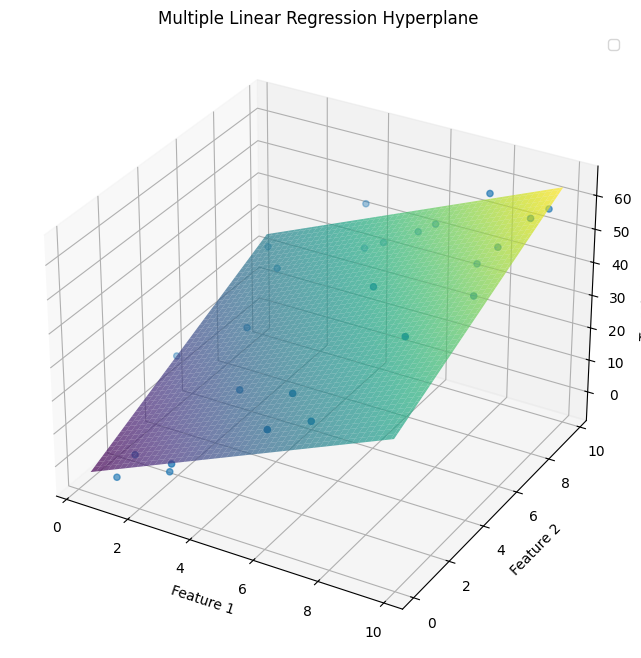

In [16]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot the surface
ax.plot_surface(x1_grid, x2_grid, y_plot, cmap='viridis', alpha=0.7, label='Regression Hyperplane')
# Scatter the actual data points
ax.scatter(X_test_multi[:, feature_indices[0]], X_test_multi[:, feature_indices[1]], y_test_multi, label='Actual Data')
# Add labels and title
ax.set_title('Multiple Linear Regression Hyperplane')
ax.set_xlabel(f'Feature {feature_indices[0] + 1}')
ax.set_ylabel(f'Feature {feature_indices[1] + 1}')
ax.set_zlabel('Target Variable')
plt.legend()
plt.show()

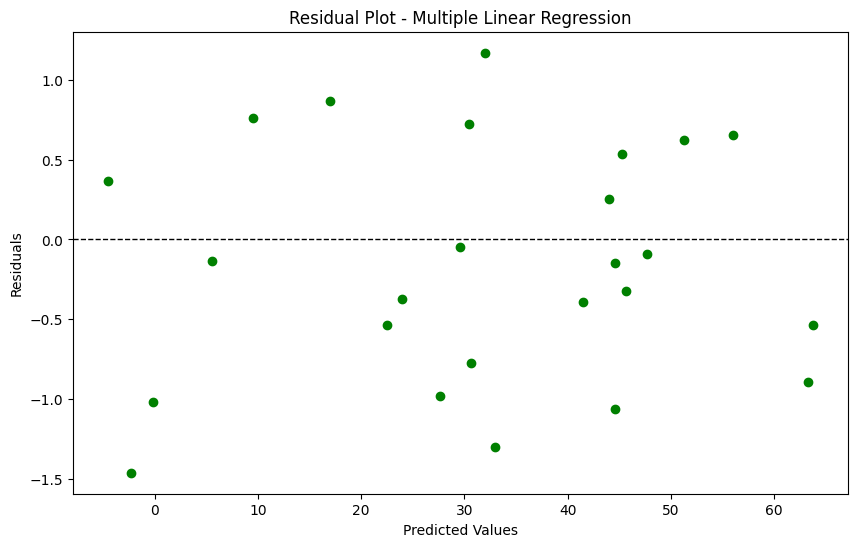

In [17]:
residuals_multi = y_test_multi - y_pred_multi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals_multi, color='green')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Multiple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [18]:
print("Simple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")
print("Multiple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_multi, y_pred_multi):.2f}")
print(f"R2 Score: {r2_score(y_test_multi, y_pred_multi):.2f}")

Simple Linear Regression Metrics:
Mean Squared Error: 4.68
R2 Score: 0.96

Multiple Linear Regression Metrics:
Mean Squared Error: 0.56
R2 Score: 1.00
